In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
import time
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.figsize': (10, 6), 'axes.titlesize': 14})

In [5]:
file_path = 'final_dataset_for_work_ecllipse.csv'

# Load the dataset
df = pd.read_csv(file_path, engine='python', on_bad_lines='skip')

print("--- DATASET OVERVIEW ---")
print(f"Total Bug Reports: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}\n")

print("--- COLUMN NAMES ---")
print(list(df.columns))

# Check for missing values
print("\n--- MISSING VALUES (NULLS) ---")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

display(df.head(3))

--- DATASET OVERVIEW ---
Total Bug Reports: 10000
Total Columns: 30

--- COLUMN NAMES ---
['Bug ID', 'Product', 'Component', 'Assignee', 'Status', 'Resolution', 'Summary', 'Changed', 'Assignee Real Name', 'Classification', 'Flags', 'Hardware', 'Keywords', 'Number of Comments', 'Opened', 'OS', 'Priority', 'QA Contact', 'QA Contact Real Name', 'Reporter', 'Reporter Real Name', 'Severity', 'Summary.1', 'Tags', 'Target Milestone', 'URL', 'Version', 'Votes', 'Whiteboard', 'Alias']

--- MISSING VALUES (NULLS) ---
Flags                    9079
Keywords                 8951
QA Contact               9845
QA Contact Real Name     9845
Reporter Real Name         33
Tags                    10000
URL                      9972
Whiteboard               9951
Alias                   10000
dtype: int64


,Bug ID,Product,Component,Assignee,Status,Resolution,Summary,Changed,Assignee Real Name,Classification,...,Reporter Real Name,Severity,Summary.1,Tags,Target Milestone,URL,Version,Votes,Whiteboard,Alias
0,3638,JDT,UI,aeschli,VERIFIED,FIXED,Package Viewer: order resource folders before ...,2002-01-17 07:28:04,Martin Aeschlimann,Eclipse,...,Martin Aeschlimann,major,Package Viewer: order resource folders before ...,NaN,---,NaN,2.0,0,NaN,NaN
1,3854,JDT,UI,aeschli,VERIFIED,FIXED,Wrong execution's classpath. (1GEY0W0),2002-01-18 04:02:11,Martin Aeschlimann,Eclipse,...,David Audel,normal,Wrong execution's classpath. (1GEY0W0),NaN,---,NaN,2.0,0,NaN,NaN
2,4188,JDT,UI,aeschli,VERIFIED,FIXED,type hierachy - typo (1GJW2XJ),2002-01-28 03:12:37,Martin Aeschlimann,Eclipse,...,Erich Gamma,normal,type hierachy - typo (1GJW2XJ),NaN,---,NaN,2.0,0,NaN,NaN


In [6]:
# Data Cleaning (Filtering, Nulls, Duplicates)

# Keep only the columns we need for the NLP model
cols_to_keep = ['Bug ID', 'Summary', 'Component', 'Severity']
df_clean = df[cols_to_keep].copy()

# Check for and remove duplicates
initial_rows = df_clean.shape[0]
df_clean.drop_duplicates(subset=['Bug ID'], inplace=True)

# Drop bugs with exact same text
df_clean.drop_duplicates(subset=['Summary'], inplace=True)
final_rows = df_clean.shape[0]

print("--- DATA CLEANING RESULTS ---")
print(f"Removed {initial_rows - final_rows} duplicate rows.")
print(f"Remaining rows: {final_rows}")
print("\nMissing values in our cleaned dataset:")
print(df_clean.isnull().sum())

--- DATA CLEANING RESULTS ---
Removed 54 duplicate rows.
Remaining rows: 9946

Missing values in our cleaned dataset:
Bug ID       0
Summary      0
Component    0
Severity     0
dtype: int64


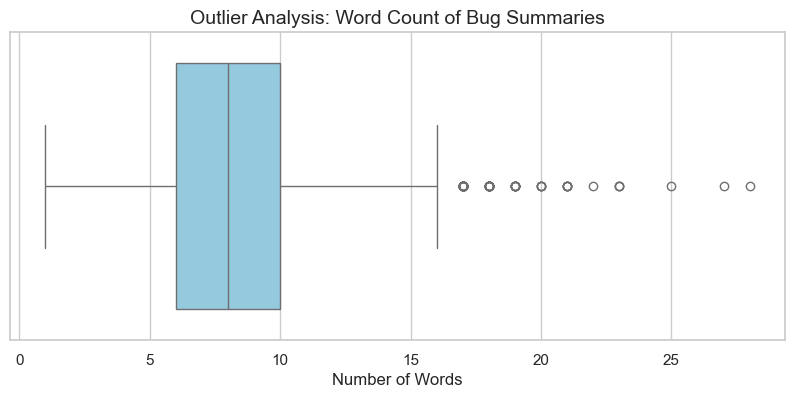

Identified 104 bugs with fewer than 3 words (potential outliers to drop).


In [7]:
# Text Cleaning and Outlier Analysis

# Function that cleans the raw text
def clean_text(text):
    # Change to lowercase
    text = str(text).lower()
    # Remove punctuation and special chars
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip() 
    return text

# Clean Summary
df_clean['Cleaned_Summary'] = df_clean['Summary'].apply(clean_text)

# Get word counts to find outliers
df_clean['Word_Count'] = df_clean['Cleaned_Summary'].apply(lambda x: len(x.split()))

# Visualize the outliers using a Boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_clean['Word_Count'], color='skyblue')
plt.title('Outlier Analysis: Word Count of Bug Summaries')
plt.xlabel('Number of Words')
plt.show()

# Check how many bugs are too short to be useful (less than 3 words)
short_bugs = df_clean[df_clean['Word_Count'] < 3].shape[0]
print(f"Identified {short_bugs} bugs with fewer than 3 words (potential outliers to drop).")

Dropped 104 excessively short bugs.
Final dataset size: 9842 rows



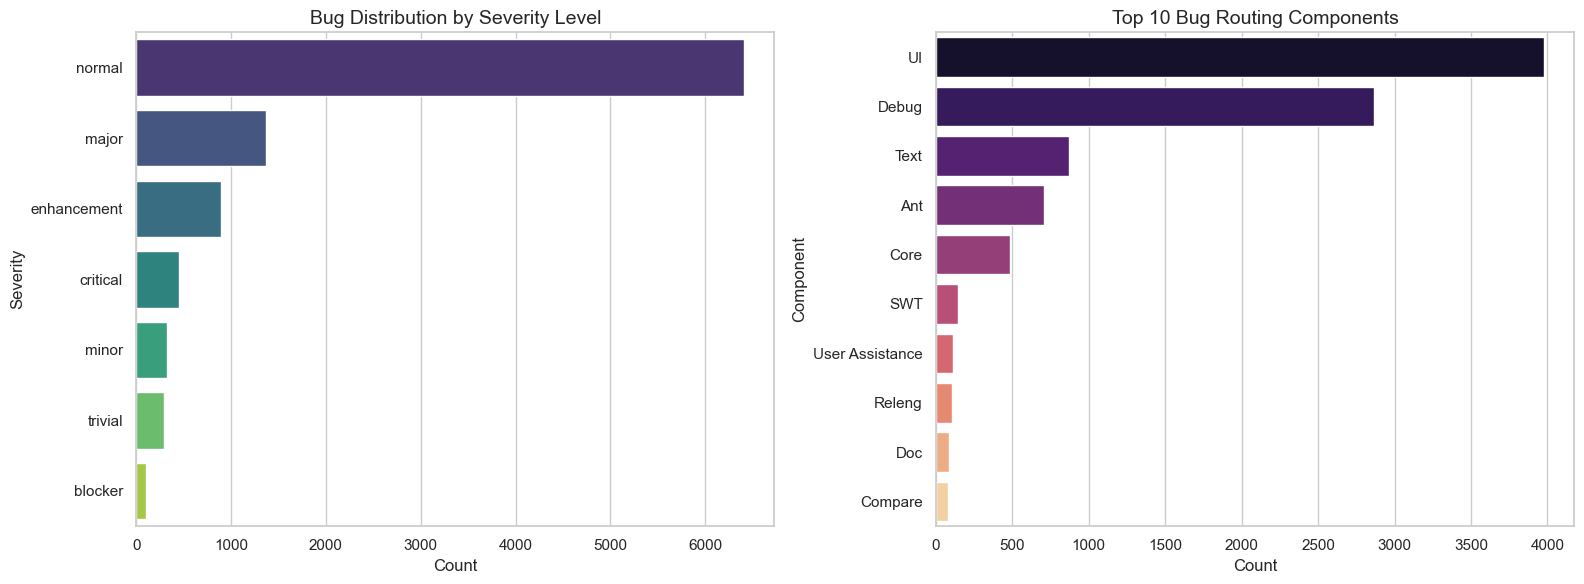

In [8]:
# Final Clean and Target Variable Distributions

# Drop outliers (bugs that are too short to provide meaningful NLP features)
df_model = df_clean[df_clean['Word_Count'] >= 3].copy()
print(f"Dropped {df_clean.shape[0] - df_model.shape[0]} excessively short bugs.")
print(f"Final dataset size: {df_model.shape[0]} rows\n")

# Visualize Categorical Variables (Severity & Component)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Severity Distribution
sns.countplot(data=df_model, y='Severity', order=df_model['Severity'].value_counts().index, 
              ax=axes[0], palette='viridis')
axes[0].set_title('Bug Distribution by Severity Level', fontsize=14)
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Severity')

# Top 10 Components (Routing Teams)
top_components = df_model['Component'].value_counts().head(10).index
sns.countplot(data=df_model[df_model['Component'].isin(top_components)], 
              y='Component', order=top_components, 
              ax=axes[1], palette='magma')
axes[1].set_title('Top 10 Bug Routing Components', fontsize=14)
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Component')

plt.tight_layout()
plt.show()

In [9]:

print("--- FEATURE ENGINEERING ---")
# Extract features using TF-IDF
# Limit to the top 5000 words to keep it fast for the baseline
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

X = tfidf.fit_transform(df_model['Cleaned_Summary'])
# target variable: The Routing Team
y = df_model['Component']

print(f"Text vectorized. Feature matrix shape: {X.shape}")

print("\n--- BASELINE MODELING ---")
# Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a baseline Logistic Regression model
# Use max_iter=1000 to ensure it converges, and class_weight='balanced'
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
print("Training Baseline Logistic Regression model...")
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

print("\n--- EVALUATION METRICS ---")
macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Baseline Macro F1-Score: {macro_f1:.4f}")

print("\nRationale for Evaluation Metric:")
print("Because the EDA revealed a severe class imbalance ")
print("(ex: 'Core' has vastly more bugs than 'UI'), standard Accuracy is misleading. ")
print("The model could achieve high accuracy simply by predicting the majority class ")
print("every time. Therefore, we use the Macro F1-Score, which calculates metrics for ")
print("each class individually and then averages them, ensuring minority routing queues ")
print("are weighted equally in our evaluation.")

# Detailed classification report for the top 5 components
print("\nClassification Report (Top 5 Components):")
# Top 5 components by frequency in the test set
top_5_classes = y_test.value_counts().head(5).index.tolist()
print(classification_report(y_test, y_pred, labels=top_5_classes))

--- FEATURE ENGINEERING ---
Text vectorized. Feature matrix shape: (9842, 5000)

--- BASELINE MODELING ---
Training Baseline Logistic Regression model...

--- EVALUATION METRICS ---
Baseline Macro F1-Score: 0.3677

Rationale for Evaluation Metric:
Because the EDA revealed a severe class imbalance 
(ex: 'Core' has vastly more bugs than 'UI'), standard Accuracy is misleading. 
The model could achieve high accuracy simply by predicting the majority class 
every time. Therefore, we use the Macro F1-Score, which calculates metrics for 
each class individually and then averages them, ensuring minority routing queues 
are weighted equally in our evaluation.

Classification Report (Top 5 Components):
              precision    recall  f1-score   support

          UI       0.79      0.53      0.63       797
       Debug       0.82      0.69      0.75       562
        Text       0.61      0.72      0.66       179
         Ant       0.79      0.70      0.74       140
        Core       0.28    

In [11]:
# Advanced Modeling & Hyperparameter Tuning

print("--- Starting Grid Search for LinearSVC ---")
# Linear SVC 
svc_param_grid = {'C': [0.1, 1, 10]}
svc_grid = GridSearchCV(LinearSVC(random_state=42, dual=False), svc_param_grid, cv=3, scoring='f1_macro', n_jobs=-1)

start_time = time.time()
svc_grid.fit(X_train, y_train)
svc_time = time.time() - start_time

print(f"Best SVC Parameters: {svc_grid.best_params_}")
print(f"Best SVC Cross-Validation Macro F1: {svc_grid.best_score_:.4f}")

# Evaluate on Test Set
svc_best = svc_grid.best_estimator_
svc_y_pred = svc_best.predict(X_test)
svc_test_f1 = f1_score(y_test, svc_y_pred, average='macro')
print(f"SVC Test Macro F1: {svc_test_f1:.4f}\n")

print("--- Starting Grid Search for Random Forest ---")
# Random Forest (Tree-based comparison)
rf_param_grid = {'n_estimators': [100, 200], 'max_depth': [None, 20]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=3, scoring='f1_macro', n_jobs=-1)

start_time = time.time()
rf_grid.fit(X_train, y_train)
rf_time = time.time() - start_time

print(f"Best RF Parameters: {rf_grid.best_params_}")
print(f"Best RF Cross-Validation Macro F1: {rf_grid.best_score_:.4f}")

# Evaluate on Test Set
rf_best = rf_grid.best_estimator_
rf_y_pred = rf_best.predict(X_test)
rf_test_f1 = f1_score(y_test, rf_y_pred, average='macro')
print(f"Random Forest Test Macro F1: {rf_test_f1:.4f}\n")

--- Starting Grid Search for LinearSVC ---
Best SVC Parameters: {'C': 1}
Best SVC Cross-Validation Macro F1: 0.3180
SVC Test Macro F1: 0.3702

--- Starting Grid Search for Random Forest ---
Best RF Parameters: {'max_depth': None, 'n_estimators': 200}
Best RF Cross-Validation Macro F1: 0.2673
Random Forest Test Macro F1: 0.3397



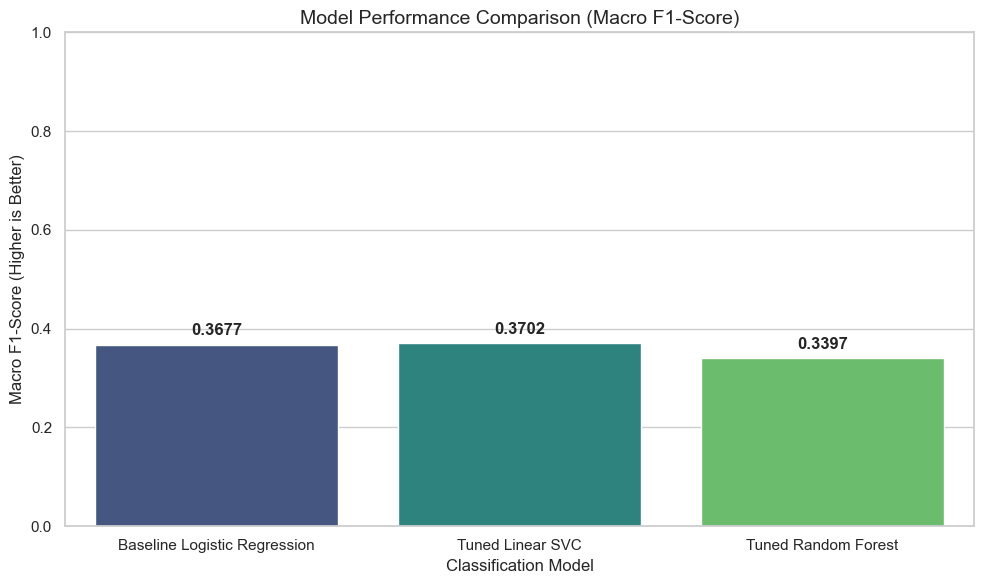

In [12]:
# Model Comparison Visualization

models = ['Baseline Logistic Regression', 'Tuned Linear SVC', 'Tuned Random Forest']
f1_scores = [macro_f1, svc_test_f1, rf_test_f1] 

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=f1_scores, palette='viridis')
plt.title('Model Performance Comparison (Macro F1-Score)', fontsize=14)
plt.ylabel('Macro F1-Score (Higher is Better)', fontsize=12)
plt.xlabel('Classification Model', fontsize=12)
plt.ylim(0, 1.0)

# Add text labels on top of the bars
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()